In [3]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import src.spaces as spaces

spaces.SETUP = spaces.make_setup_uv()

from src.training import (
    train, loss_fn, loss_fn_fa, loss_fn_ea, loss_fn_da, DEFAULT_CONFIG,
)
from src.teacher import make_wi_particles, make_arbitrary_particles, sample_data
from src.metrics import rmd_to_projected

N_VALUES = [5, 10, 50, 100, 500]
N_REPS = 3
CONFIG = {**DEFAULT_CONFIG, "T": 20.0, "gr": 5}
CONFIG["alpha"]=5.0
CONFIG['tau'] = 0.03

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
print(CONFIG)

{'alpha': 5.0, 'tau': 0.03, 'beta': 1e-06, 'batch_size': 20, 'T': 20.0, 'gr': 5}


In [5]:
teacher_wi = make_wi_particles()

results_wi = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for N in N_VALUES:
    for name in results_wi:
        results_wi[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        # Vanilla
        h = train(teacher_wi, N, jax.random.fold_in(key, 0), CONFIG, "si")
        results_wi["vanilla"][-1].append(rmd_to_projected(h["particles"][-1]))

        # DA
        h = train(teacher_wi, N, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da)
        results_wi["DA"][-1].append(rmd_to_projected(h["particles"][-1]))

        # FA
        h = train(teacher_wi, N, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa)
        results_wi["FA"][-1].append(rmd_to_projected(h["particles"][-1]))

        # EA
        h = train(teacher_wi, N, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea)
        results_wi["EA"][-1].append(rmd_to_projected(h["particles"][-1]))

    print(f"N={N} done")

W0413 18:21:25.954112 5711017 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


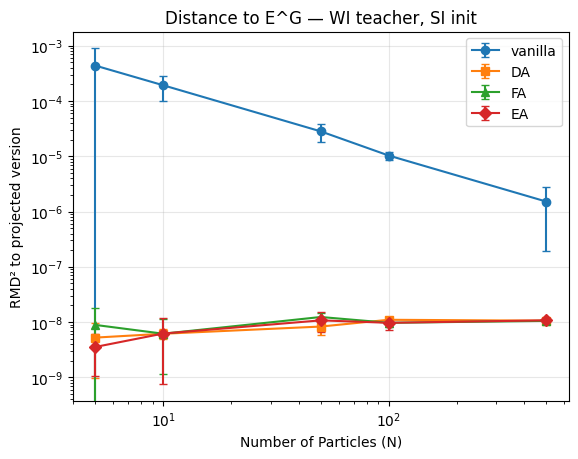

In [6]:
markers = {"vanilla": "o", "DA": "s", "FA": "^", "EA": "D"}

for name in results_wi:
    means = [jnp.mean(jnp.array(r)) for r in results_wi[name]]
    stds = [jnp.std(jnp.array(r)) for r in results_wi[name]]
    plt.errorbar(N_VALUES, means, yerr=stds, marker=markers[name],
                 label=name, capsize=3)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of Particles (N)")
plt.ylabel("RMD² to projected version")
plt.title("Distance to E^G — WI teacher, SI init")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [7]:
teacher_arb = make_arbitrary_particles()

results_arb = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for N in N_VALUES:
    for name in results_arb:
        results_arb[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train(teacher_arb, N, jax.random.fold_in(key, 0), CONFIG, "si")
        results_arb["vanilla"][-1].append(rmd_to_projected(h["particles"][-1]))

        h = train(teacher_arb, N, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da)
        results_arb["DA"][-1].append(rmd_to_projected(h["particles"][-1]))

        h = train(teacher_arb, N, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa)
        results_arb["FA"][-1].append(rmd_to_projected(h["particles"][-1]))

        h = train(teacher_arb, N, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea)
        results_arb["EA"][-1].append(rmd_to_projected(h["particles"][-1]))

    print(f"N={N} done")

N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


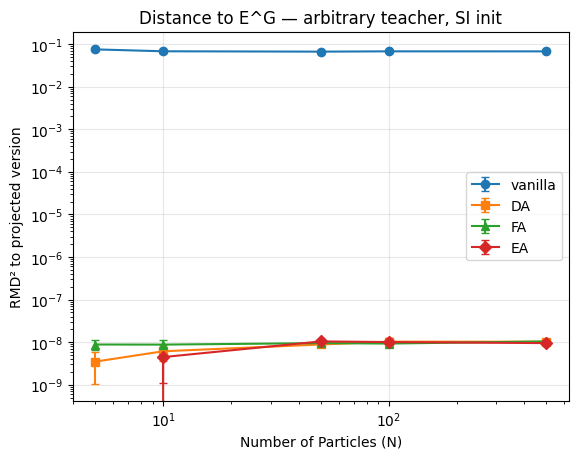

In [8]:
for name in results_arb:
    means = [jnp.mean(jnp.array(r)) for r in results_arb[name]]
    stds = [jnp.std(jnp.array(r)) for r in results_arb[name]]
    plt.errorbar(N_VALUES, means, yerr=stds, marker=markers[name],
                 label=name, capsize=3)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of Particles (N)")
plt.ylabel("RMD² to projected version")
plt.title("Distance to E^G — arbitrary teacher, SI init")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [9]:
teacher = make_wi_particles()
N = 500
key = jax.random.PRNGKey(42)

configs = {"alpha": 5.0, "tau": 0.03, "beta": 1e-6, "batch_size": 20, "T": 20.0, "gr": 5}

h_vanilla = train(teacher, N, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
h_da = train(teacher, N, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da)
print("DA done")
h_fa = train(teacher, N, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa)
print("FA done")
h_ea = train(teacher, N, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea)
print("EA done")

vanilla done
DA done
FA done
EA done


In [10]:
import plotly.graph_objects as go
import jax.numpy as jnp

def plot_particles_3d(student_particles, teacher_particles, title):
    """3D scatter: axes = z1, z2, z3, color = z4."""
    # Flatten (N, 2, 2) → (N, 4)
    S = jnp.array(student_particles).reshape(-1, 4)
    T = jnp.array(teacher_particles).reshape(-1, 4)

    fig = go.Figure()

    # Student particles (small dots)
    fig.add_trace(go.Scatter3d(
        x=S[:, 0], y=S[:, 1], z=S[:, 2],
        mode='markers',
        marker=dict(size=2, color=S[:, 3], colorscale='Viridis',
                    colorbar=dict(title='z4'), cmin=-0.6, cmax=0.6),
        name='Student',
    ))

    # Teacher particles (big diamonds)
    fig.add_trace(go.Scatter3d(
        x=T[:, 0], y=T[:, 1], z=T[:, 2],
        mode='markers',
        marker=dict(size=6, color=T[:, 3], colorscale='Viridis',
                    symbol='diamond', cmin=-0.6, cmax=0.6,
                    line=dict(width=1, color='black')),
        name='Teacher',
    ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='z1', yaxis_title='z2', zaxis_title='z3',
            xaxis=dict(range=[-0.6, 0.6]),
            yaxis=dict(range=[-0.6, 0.6]),
            zaxis=dict(range=[-0.6, 0.6]),
        ),
        width=700, height=600,
    )
    fig.show()

In [11]:
plot_particles_3d(h_vanilla["particles"][-1], teacher, "Student Particles (vanilla)")

In [25]:
import numpy as np
parts = np.array(h_vanilla['particles'][-1])

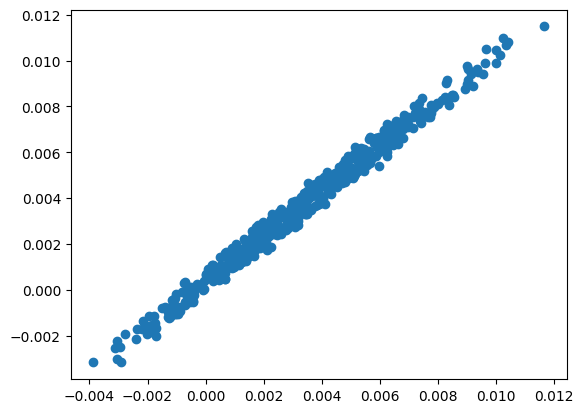

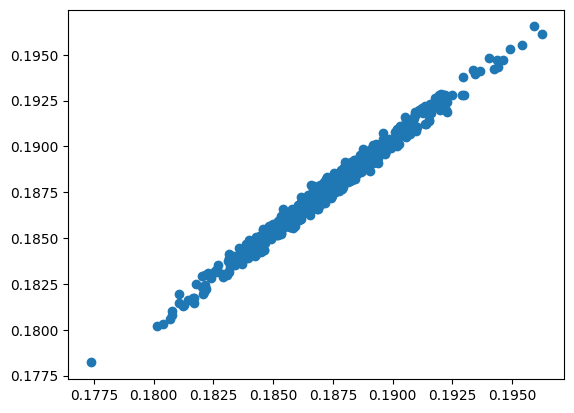

In [28]:
plt.scatter(parts[:,0,0], parts[:, 0, 1])
plt.figure()
plt.scatter(parts[:, 1, 0], parts[:, 1, 1])

In [12]:
plot_particles_3d(h_da["particles"][-1], teacher, "Student Particles (DA)")

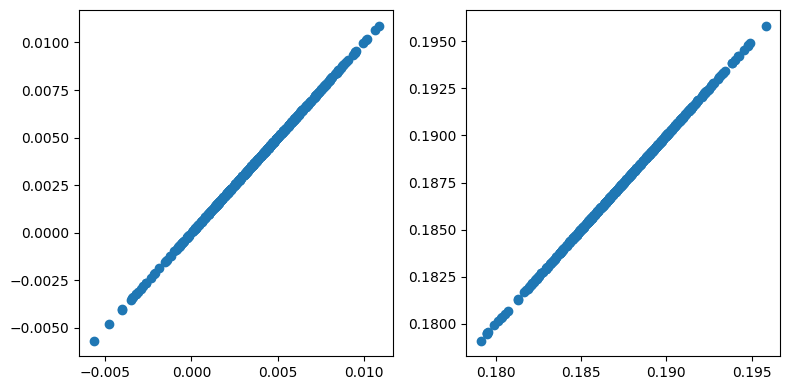

In [45]:
da_parts = np.array(h_da['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(da_parts[:, 0, 0], da_parts[:, 0, 1])
ax[1].scatter(da_parts[:, 1, 0], da_parts[:, 1, 1])
plt.tight_layout()

In [13]:
plot_particles_3d(h_fa["particles"][-1], teacher, "Student Particles (FA)")

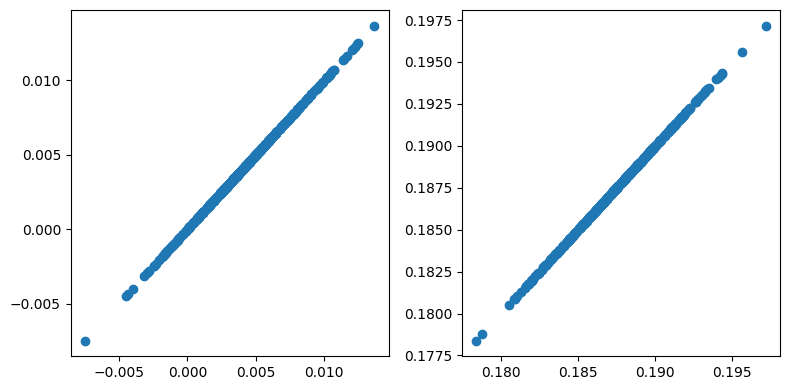

In [46]:
fa_parts = np.array(h_fa['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(fa_parts[:, 0, 0], fa_parts[:, 0, 1])
ax[1].scatter(fa_parts[:, 1, 0], fa_parts[:, 1, 1])
plt.tight_layout()

In [11]:
plot_particles_3d(h_ea["particles"][-1], teacher, "Student Particles (EA)")

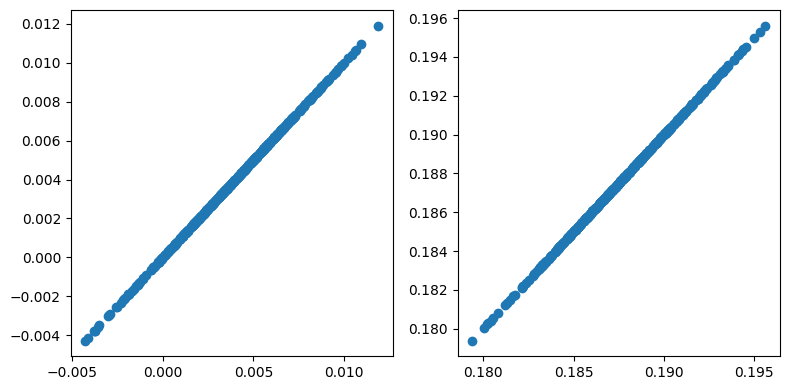

In [42]:
ea_parts = np.array(h_ea['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(ea_parts[:, 0, 0], ea_parts[:, 0, 1])
ax[1].scatter(ea_parts[:, 1, 0], ea_parts[:, 1, 1])
plt.tight_layout()

In [14]:
from src.teacher import make_arbitrary_particles

teacher_arb = make_arbitrary_particles()

h_vanilla_arb = train(teacher_arb, N, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
h_da_arb = train(teacher_arb, N, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da)
print("DA done")
h_fa_arb = train(teacher_arb, N, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa)
print("FA done")
h_ea_arb = train(teacher_arb, N, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea)
print("EA done")

vanilla done
DA done
FA done
EA done


In [29]:
plot_particles_3d(h_vanilla_arb["particles"][-1], teacher_arb, "Arbitrary teacher — vanilla")

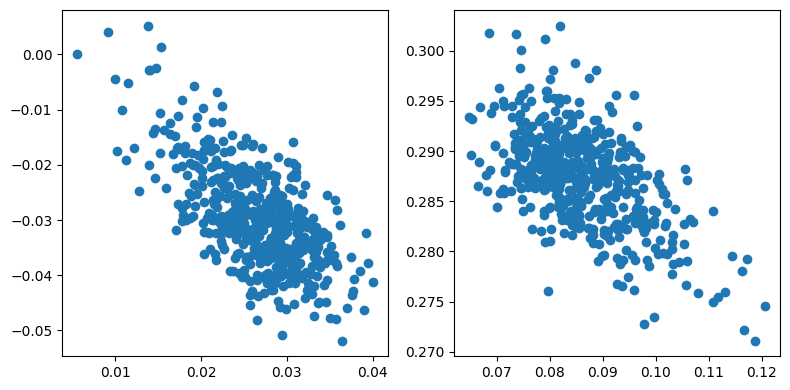

In [ ]:
va_parts_arb = np.array(h_vanilla_arb['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(va_parts_arb[:, 0, 0], va_parts_arb[:, 0, 1])
ax[1].scatter(va_parts_arb[:, 1, 0], va_parts_arb[:, 1, 1])
plt.tight_layout()

In [30]:
plot_particles_3d(h_da_arb["particles"][-1], teacher_arb, "Arbitrary teacher — DA")

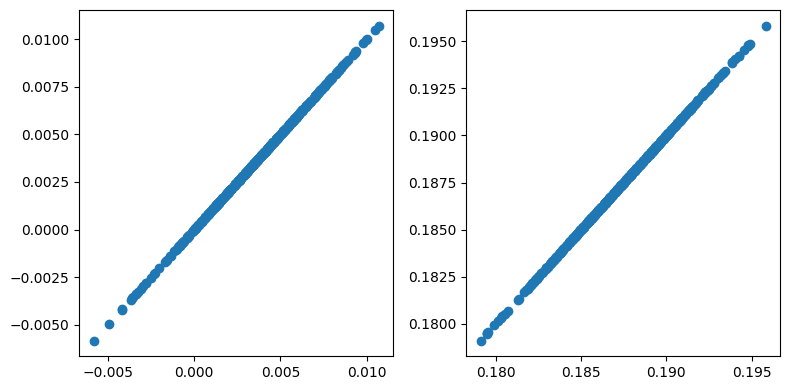

In [43]:
da_parts_arb = np.array(h_da_arb['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(da_parts_arb[:, 0, 0], da_parts_arb[:, 0, 1])
ax[1].scatter(da_parts_arb[:, 1, 0], da_parts_arb[:, 1, 1])
plt.tight_layout()

In [31]:
plot_particles_3d(h_fa_arb["particles"][-1], teacher_arb, "Arbitrary teacher — FA")

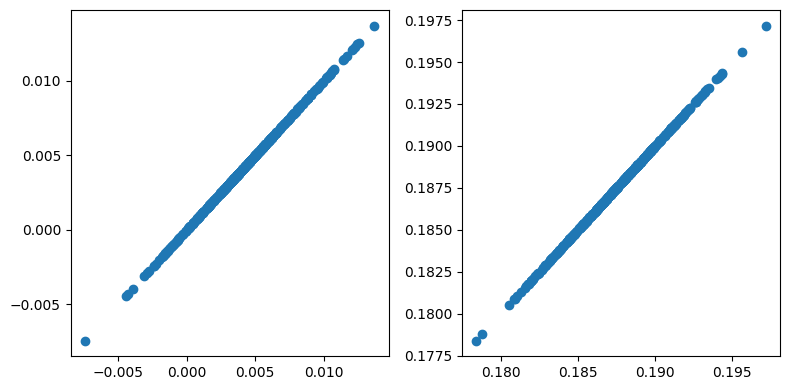

In [ ]:
fa_parts_arb = np.array(h_fa_arb['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(fa_parts_arb[:, 0, 0], fa_parts_arb[:, 0, 1])
ax[1].scatter(fa_parts_arb[:, 1, 0], fa_parts_arb[:, 1, 1])
plt.tight_layout()

In [32]:
plot_particles_3d(h_ea_arb["particles"][-1], teacher_arb, "Arbitrary teacher — EA")

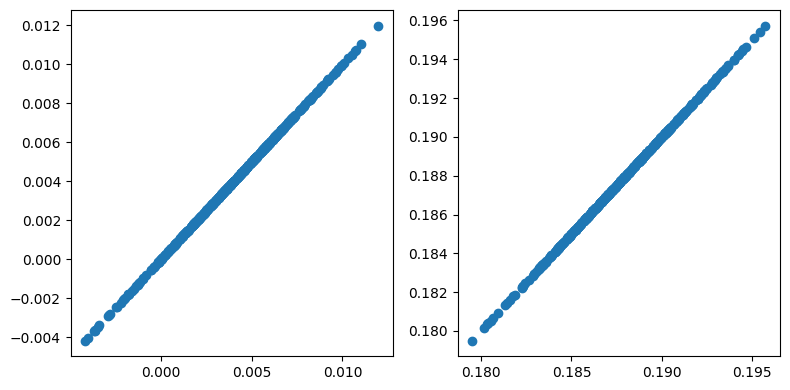

In [44]:
ea_parts_arb = np.array(h_ea_arb['particles'][-1])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(ea_parts_arb[:, 0, 0], ea_parts_arb[:, 0, 1])
ax[1].scatter(ea_parts_arb[:, 1, 0], ea_parts_arb[:, 1, 1])
plt.tight_layout()